What this model does:

Input: one row of data describing a single website visit, how many pages they looked at, how long they stayed, what month it is, etc.

Model: a classifier that learns patterns from past visits to guess what happens next. I'm comparing Logistic Regression, Random Forest, and XGBoost.

Output: a probability (like 73%) that this particular visit will end in a purchase.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/WorthWise/online_shoppers_intention.csv')

# **Data understanding/graphing section**

In [ ]:
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal duplicate rows:", df.duplicated().sum())

Missing values per column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Total duplicate rows: 125


This chart shows how many browsing sessions ended in a purchase vs. how many didn't. Out of 12,330 sessions, only about 15.5% resulted in a purchase, most people browse without buying. This matters a lot for building the model: since "no purchase" is so much more common, the model needs to be evaluated carefully later (accuracy alone would be misleading, since even a lazy model that always guesses "no purchase" would look right most of the time).

Revenue
False    10422
True      1908
Name: count, dtype: int64
Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


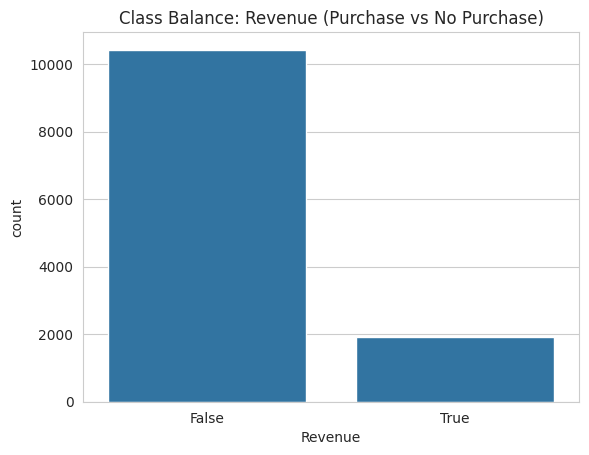

In [ ]:
print(df["Revenue"].value_counts())
print(df["Revenue"].value_counts(normalize=True))

sns.countplot(x="Revenue", data=df)
plt.title("Class Balance: Revenue (Purchase vs No Purchase)")
plt.show()

In [ ]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


These histograms show the shape of each numeric feature, how much time people spend on pages, how often they bounce off the site, etc. Most of these are heavily skewed: a big spike of sessions near zero, then a long thin tail stretching out to a few extreme values (some sessions last hours, which is likely an idle tab, not real browsing). This tells us these features aren't evenly distributed, which we'll need to account for when preparing the data for the model.

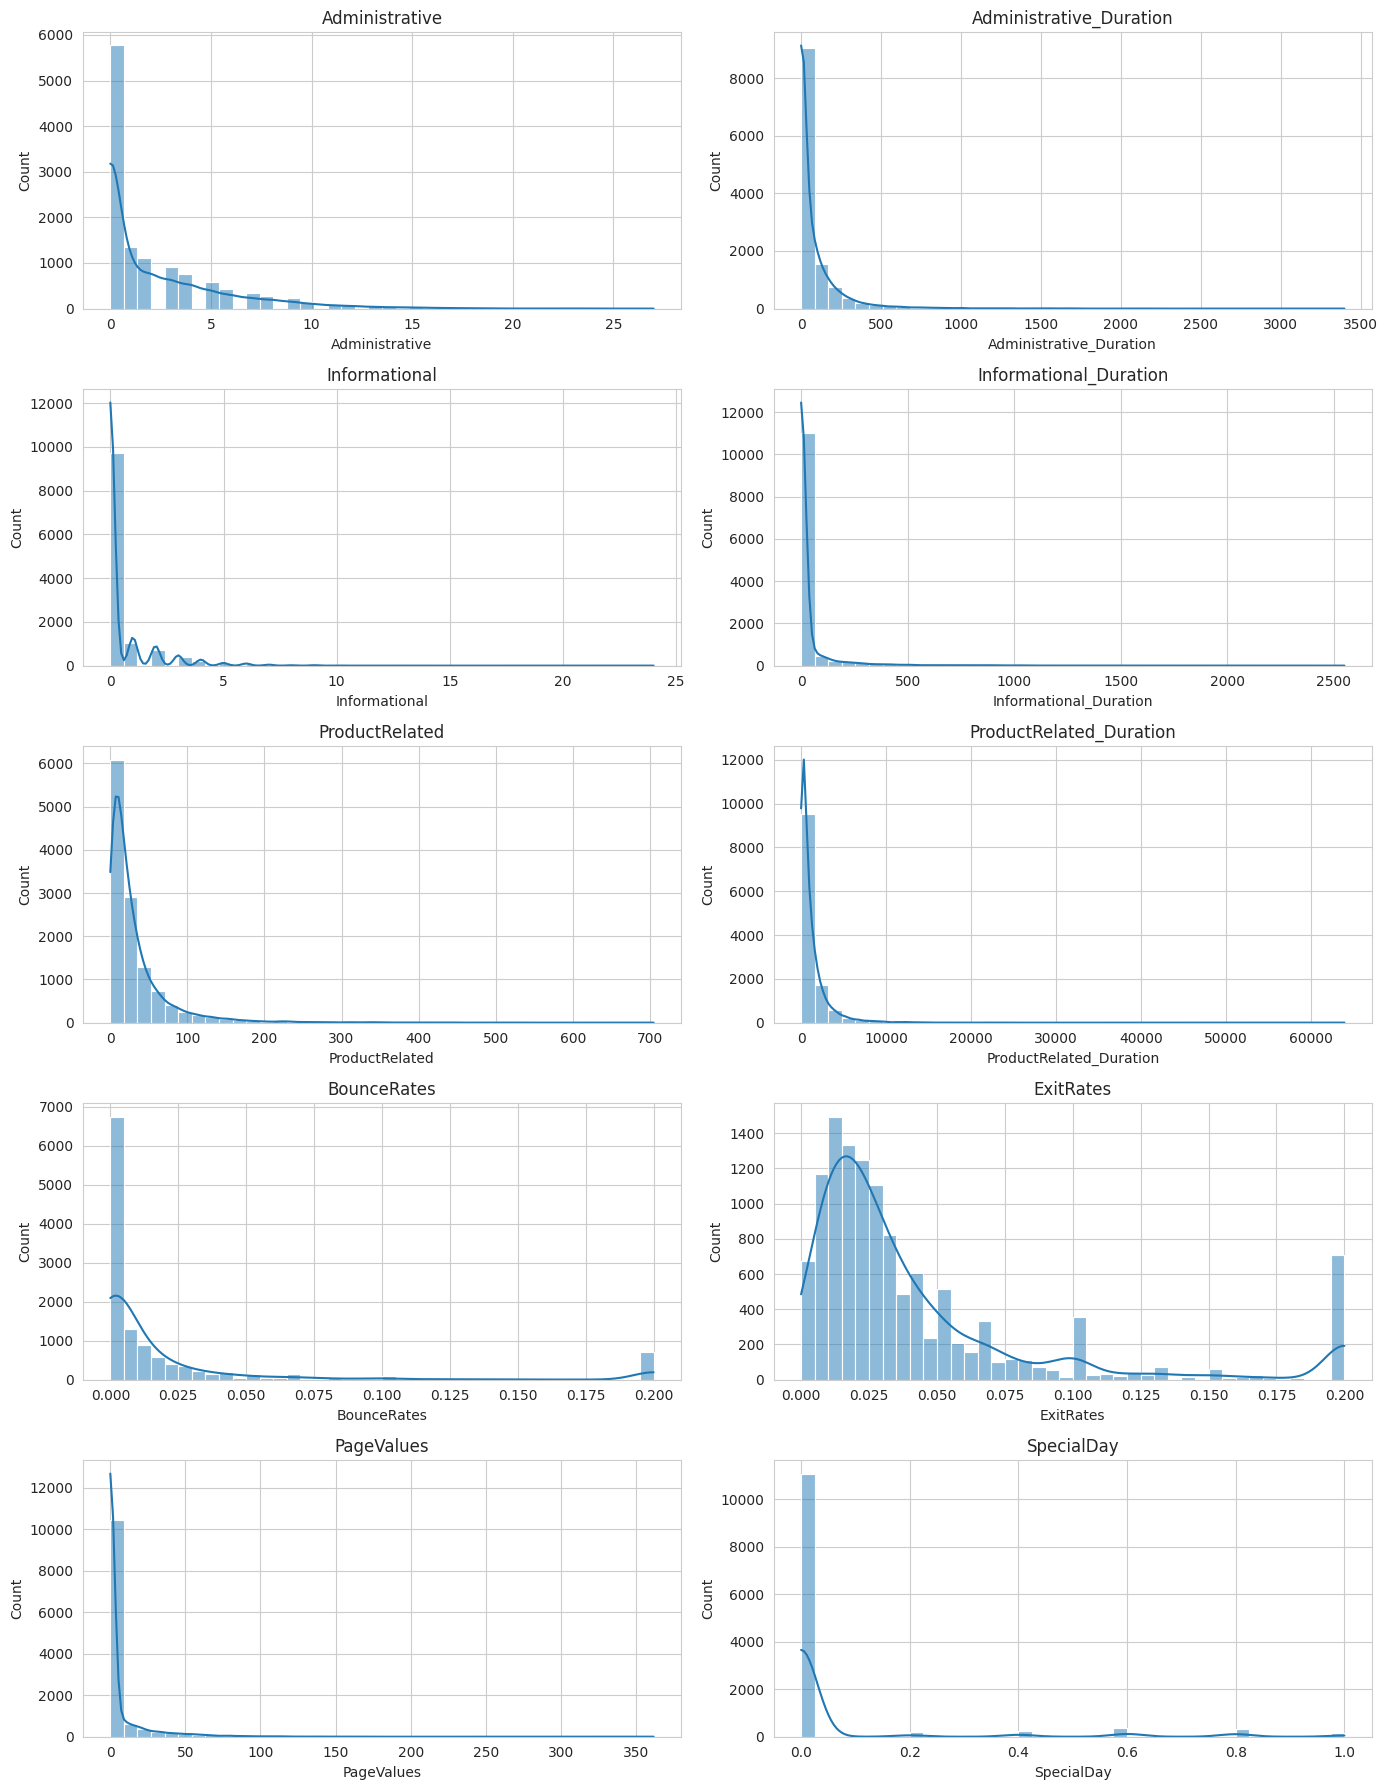

In [ ]:
numeric_cols = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=40, ax=axes[i], kde=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

These bar charts describe the makeup of the sessions in the dataset, which months, browsers, regions, and visitor types show up most often. This isn't about purchases yet, just a snapshot of who's in the data. For example, most sessions come from returning visitors, and traffic isn't evenly spread across months.

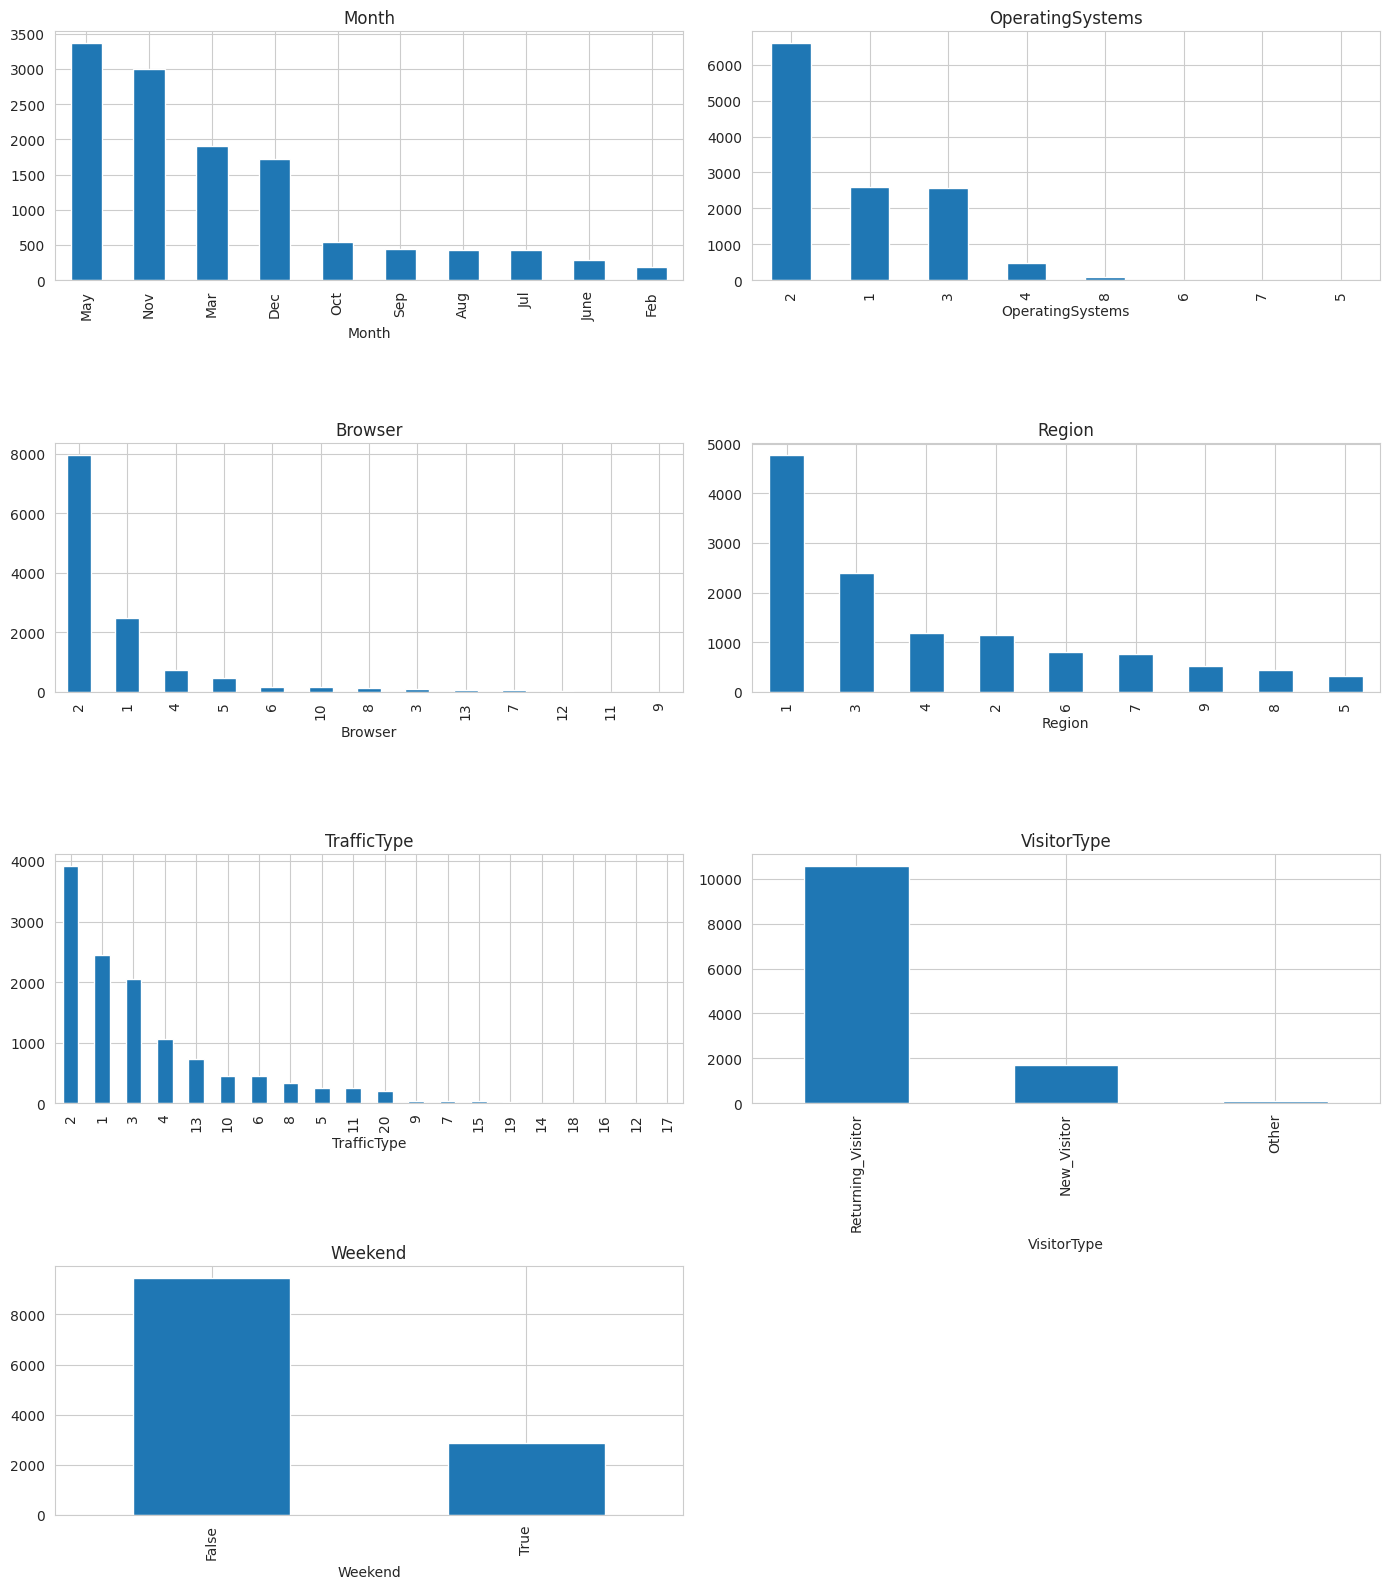

In [ ]:
categorical_cols = ["Month", "OperatingSystems", "Browser", "Region",
                     "TrafficType", "VisitorType", "Weekend"]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind="bar", ax=axes[i])
    axes[i].set_title(col)

axes[-1].axis("off")  # hide the unused subplot
plt.tight_layout()
plt.show()

This heatmap shows how strongly each numeric feature relates to whether someone made a purchase. Darker red = strongly connected to buying, darker blue = strongly connected to not buying.

The standout here is PageValues, it has by far the strongest positive connection to purchases (0.49). This is a Google Analytics score representing how valuable the pages someone visited tend to be, and it's clearly the most important signal in the dataset. ExitRates has the strongest negative connection (-0.21), the more often someone exits mid-session, the less likely they are to buy. Everything else (page counts, admin pages, special day proximity) has a much weaker relationship on its own.

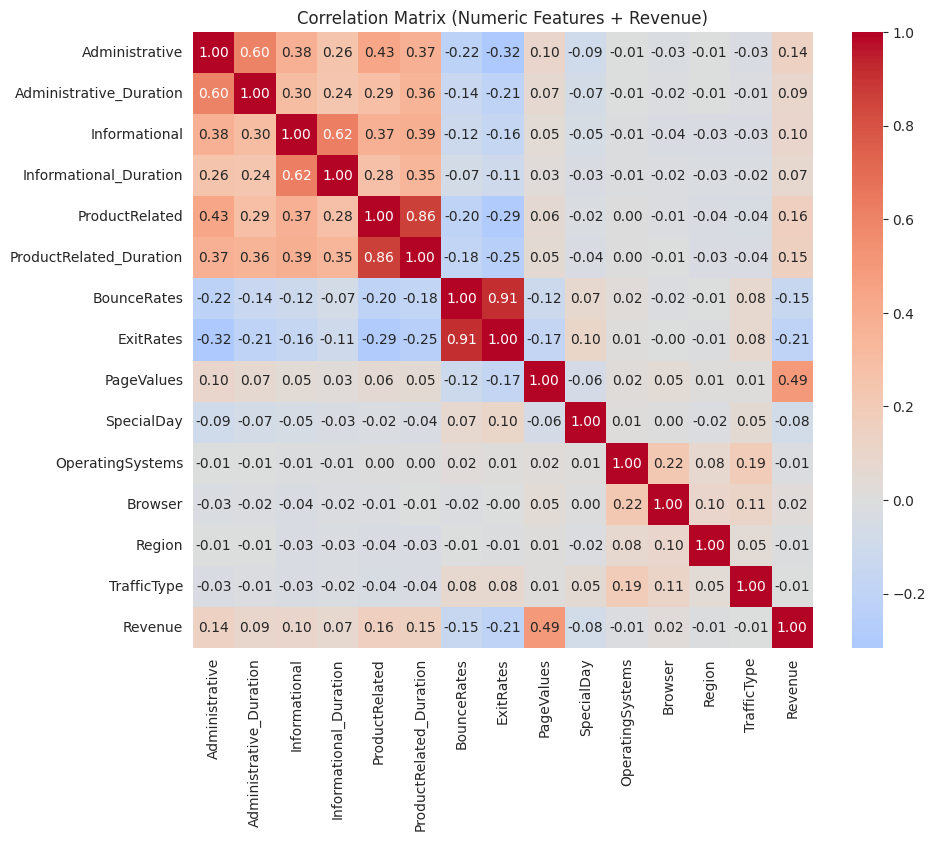

Revenue                    1.000000
PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
Browser                    0.023984
TrafficType               -0.005113
Region                    -0.011595
OperatingSystems          -0.014668
SpecialDay                -0.082305
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: float64


In [ ]:
corr = df.select_dtypes(include=np.number).copy()
corr["Revenue"] = df["Revenue"].astype(int)

corr_matrix = corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features + Revenue)")
plt.show()

print(corr_matrix["Revenue"].sort_values(ascending=False))

Each box compares people who bought something against people who didn't, for one feature at a time. The line in the middle of each box is the typical (median) value; the box itself covers the middle 50% of sessions.

PageValues: buyers have a typical value of ~17, non-buyers ~0 a huge, clear difference.

ProductRelated_Duration: buyers spend roughly twice as long browsing product pages (about 1,110 seconds vs. 510 seconds).

ExitRates: buyers exit less often mid-browsing (0.016) than non-buyers (0.029).

When the two boxes barely overlap, it means that feature is a strong signal for telling buyers and non-buyers apart, good news for the model.

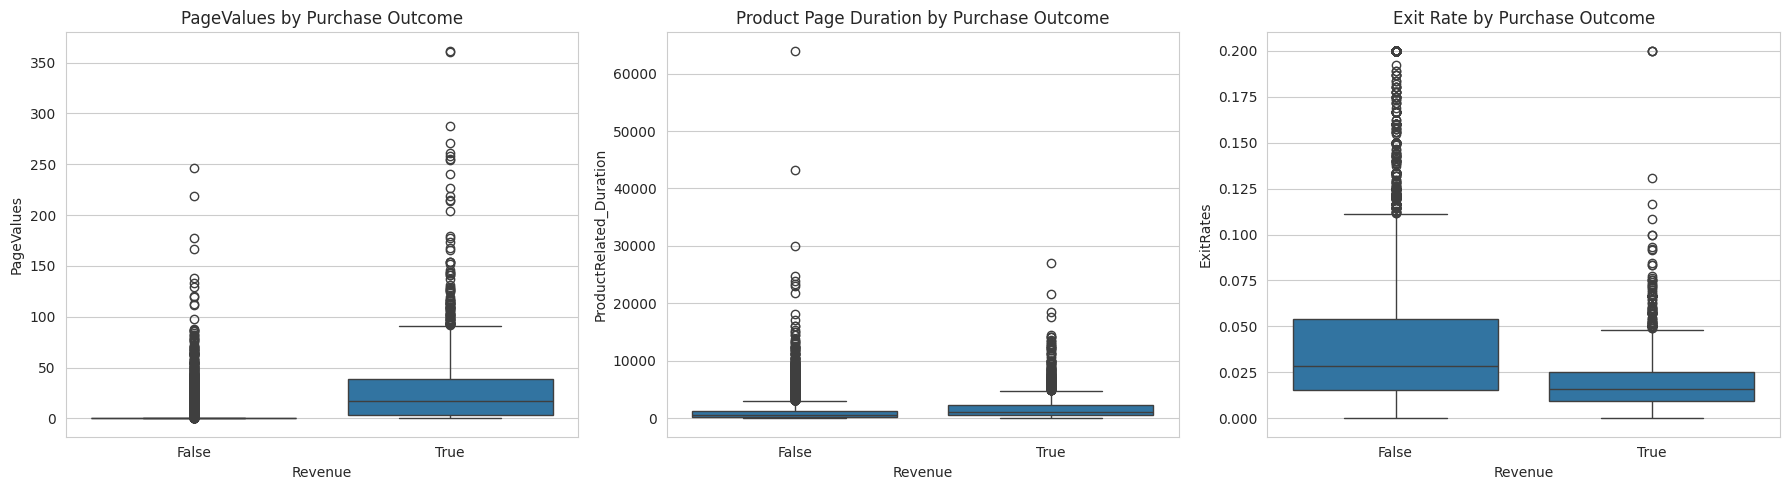

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x="Revenue", y="PageValues", data=df, ax=axes[0])
axes[0].set_title("PageValues by Purchase Outcome")

sns.boxplot(x="Revenue", y="ProductRelated_Duration", data=df, ax=axes[1])
axes[1].set_title("Product Page Duration by Purchase Outcome")

sns.boxplot(x="Revenue", y="ExitRates", data=df, ax=axes[2])
axes[2].set_title("Exit Rate by Purchase Outcome")

plt.tight_layout()
plt.show()

This chart shows what percentage of sessions end in a purchase, month by month. The purchase rate climbs steadily from February through November, jumping from just 1.6% in February to a peak of 25.4% in November, over 15x higher. That November spike lines up with Black Friday/Cyber Monday shopping season. Purchases dip again in December, likely because the big shopping rush has already passed.

Interestingly, proximity to a "Special Day" (like Valentine's Day) shows a slightly negative relationship with purchases, meaning being close to one of these dates doesn't automatically make someone more likely to buy on this site.

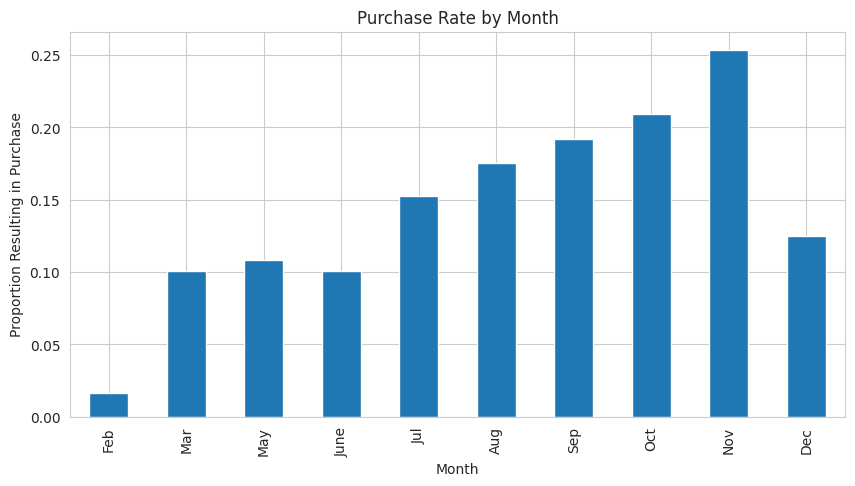

SpecialDay
0.0    0.165268
0.2    0.078652
0.4    0.053498
0.6    0.082621
0.8    0.033846
1.0    0.064935
Name: Revenue, dtype: float64


In [ ]:
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

purchase_by_month = df.groupby("Month")["Revenue"].mean().reindex(month_order)
purchase_by_month.plot(kind="bar", figsize=(10, 5))
plt.title("Purchase Rate by Month")
plt.ylabel("Proportion Resulting in Purchase")
plt.show()

purchase_by_special_day = df.groupby("SpecialDay")["Revenue"].mean()
print(purchase_by_special_day)

PCA(Principal Component Analysis) setup and scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Use only the numeric behavioral features (PCA doesn't work on categorical data directly)
numeric_features = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]

X_numeric = df[numeric_features]

#PCA is sensitive to scaleso standardize first (mean=0, std=1 for each feature)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

Run PCA and check how much variance is captured

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variance explained by each component:", pca.explained_variance_ratio_)
print("Total variance captured by 2 components:", sum(pca.explained_variance_ratio_).round(3))

Variance explained by each component: [0.3400384  0.16751818]
Total variance captured by 2 components: 0.508


Plot PC1 vs PC2, colored by Revenue

PCA takes all 10 numeric features and compresses them down into just 2 new combined features (PC1 and PC2) that capture as much of the original information as possible. This lets us plot every session as a single point on a 2D graph, even though it originally had 10 dimensions.

Each point is one session: gray if they didn't buy, red if they did. If the red and gray points form separate clusters, it means these features do a good job of naturally distinguishing buyers from non-buyers, which is a strong sign the model will be able to learn this pattern well. If the two colors are mixed together with no clear separation, it means the classes overlap a lot and the model will have a harder time telling them apart from these features alone.

Note: the printed "variance explained" number tells how much of the original information survived the compression down to 2 dimensions if it's low (e.g., under 50%), keep in mind this 2D picture is a simplified view, not the full story.

PC1 (Principal Component 1) is the one direction through thr data that captures the most variance, it's the single "axis" along which your sessions differ from each other the most. It's a weighted mix of all 10 original features(numerical features). The exact weights are called "loadings."

PC2 is the direction that captures the second-most variance, with the constraint that it's completely uncorrelated with PC1 (mathematically, perpendicular to it).

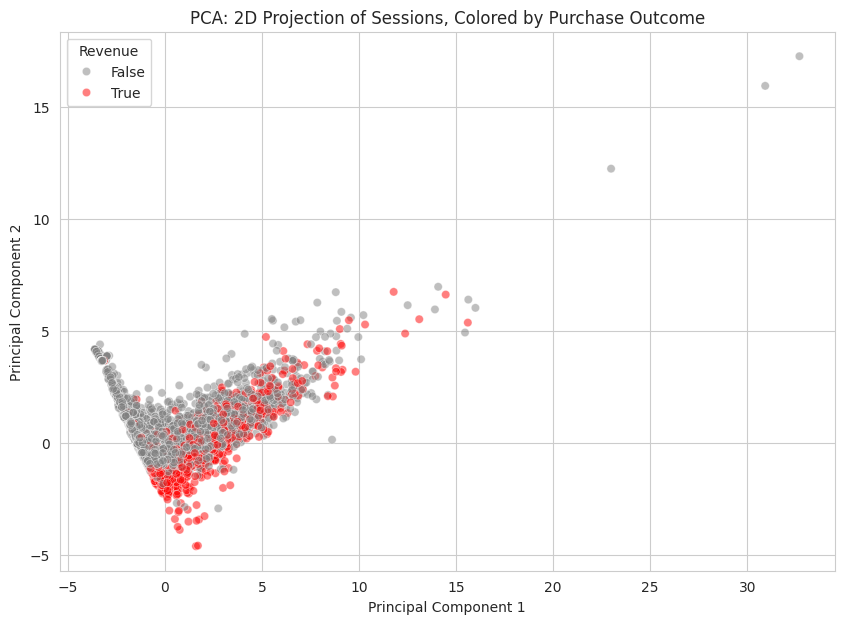

In [ ]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Revenue"] = df["Revenue"].values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Revenue", alpha=0.5, palette=["gray", "red"])
plt.title("PCA: 2D Projection of Sessions, Colored by Purchase Outcome")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

This chart shows what happens as we allow PCA to use more and more components instead of just 2. Each point on the line shows the total variance captured using that many components. If the line rises quickly and flattens out early, it means a few components already capture most of the story. If it climbs slowly and needs most/all components to reach 90% (the red dashed line), it means the information in this dataset is spread out across many features, without much redundancy.

This tells us whether the messy/overlapping look of the earlier 2D PCA plot (which only captured 50.8% of variance) is expected, if it takes many components to reach 90%, then 2 components were never going to be enough to show a clean separation, and that's just the nature of this data, not a mistake.

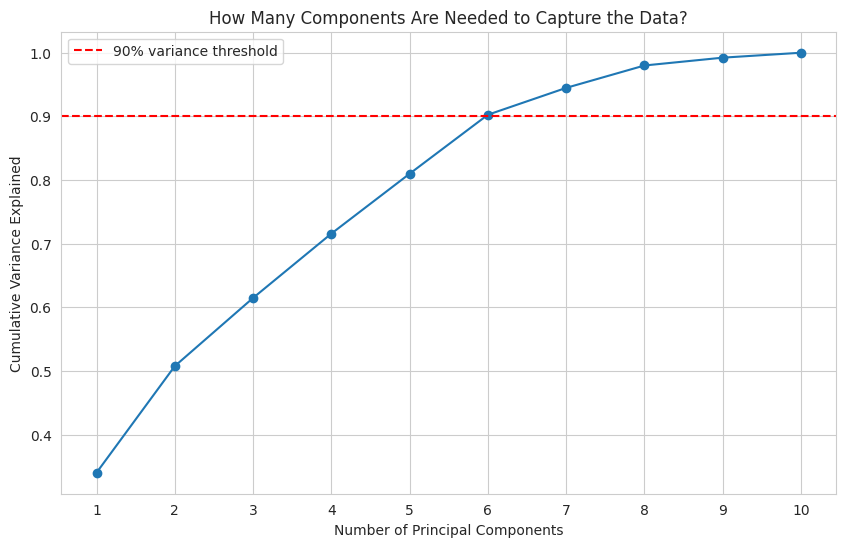

Components needed to reach 90% variance: 6
Cumulative variance by component:
[0.34  0.508 0.615 0.716 0.81  0.903 0.945 0.98  0.992 1.   ]


In [ ]:
pca_full = PCA(n_components=len(numeric_features))
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.90, color="red", linestyle="--", label="90% variance threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("How Many Components Are Needed to Capture the Data?")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.grid(True)
plt.show()

#Print the exact number of components needed to hit 90%
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed to reach 90% variance: {n_components_90}")
print(f"Cumulative variance by component:\n{cumulative_variance.round(3)}")

# **Preprocessing**

In [ ]:
from sklearn.model_selection import train_test_split

df_model = df.copy()

#Convert target to binary integers (True/False -> 1/0)
df_model["Revenue"] = df_model["Revenue"].astype(int)
df_model["Weekend"] = df_model["Weekend"].astype(int)

#One-hot encode the true categorical columns
categorical_cols = ["Month", "VisitorType", "OperatingSystems", "Browser", "Region", "TrafficType"]

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print("Shape before encoding:", df_model.shape)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape before encoding: (12330, 18)
Shape after encoding: (12330, 69)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,OperatingSystems_2,OperatingSystems_3,OperatingSystems_4,OperatingSystems_5,OperatingSystems_6,OperatingSystems_7,OperatingSystems_8,Browser_2,Browser_3,Browser_4,Browser_5,Browser_6,Browser_7,Browser_8,Browser_9,Browser_10,Browser_11,Browser_12,Browser_13,Region_2,Region_3,Region_4,Region_5,Region_6,Region_7,Region_8,Region_9,TrafficType_2,TrafficType_3,TrafficType_4,TrafficType_5,TrafficType_6,TrafficType_7,TrafficType_8,TrafficType_9,TrafficType_10,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,0,0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,0,0,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,0,0,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,0,0,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,1,0,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
X = df_encoded.drop(columns=["Revenue"])
y = df_encoded["Revenue"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y class balance:\n", y.value_counts(normalize=True))

X shape: (12330, 68)
y shape: (12330,)
y class balance:
 Revenue
0    0.845255
1    0.154745
Name: proportion, dtype: float64


Stratified train/test split(equal percentage)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          #keeps the same purchase ratio in train and test
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))

Train shape: (9864, 68)
Test shape: (2466, 68)

Train class balance:
 Revenue
0    0.845296
1    0.154704
Name: proportion, dtype: float64

Test class balance:
 Revenue
0    0.845093
1    0.154907
Name: proportion, dtype: float64


Scale numeric features (fit on train, apply to both)

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_cols_to_scale = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]

scaler_final = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols_to_scale] = scaler_final.fit_transform(X_train[numeric_cols_to_scale])
X_test_scaled[numeric_cols_to_scale] = scaler_final.transform(X_test[numeric_cols_to_scale])

X_train_scaled.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,OperatingSystems_2,OperatingSystems_3,OperatingSystems_4,OperatingSystems_5,OperatingSystems_6,OperatingSystems_7,OperatingSystems_8,Browser_2,Browser_3,Browser_4,Browser_5,Browser_6,Browser_7,Browser_8,Browser_9,Browser_10,Browser_11,Browser_12,Browser_13,Region_2,Region_3,Region_4,Region_5,Region_6,Region_7,Region_8,Region_9,TrafficType_2,TrafficType_3,TrafficType_4,TrafficType_5,TrafficType_6,TrafficType_7,TrafficType_8,TrafficType_9,TrafficType_10,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
4263,1.712088,3.624745,-0.395782,-0.244589,0.058405,0.083393,-0.353793,-0.612923,0.341014,3.663440,0,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5905,-0.698294,-0.452341,-0.395782,-0.244589,-0.629459,-0.539163,0.360698,1.159262,-0.320268,-0.311499,1,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9434,-0.698294,-0.452341,-0.395782,-0.244589,-0.629459,-0.599504,-0.458865,0.136746,-0.320268,-0.311499,0,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3505,-0.095698,1.429605,-0.395782,-0.244589,-0.331385,0.009963,-0.202751,-0.118883,0.716100,3.663440,0,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2067,-0.698294,-0.452341,-0.395782,-0.244589,0.012548,-0.187989,-0.458865,-0.873776,2.625461,-0.311499,0,False,False,False,False,True,False,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


Handling the Class Imbalance

Since only ~15.5% of sessions result in a purchase, models trained naively tend to just predict "no purchase" most of the time and still look decent on paper. We'll set up two different strategies to correct for this, and compare both once we get to training:

Class weighting: tell the model to treat mistakes on the rare "purchase" class as more costly, without changing the data itself.

SMOTE (Synthetic Minority Oversampling): generate synthetic new "purchase" examples in the training set only, so the classes are numerically balanced before training.

In [ ]:
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

In [ ]:
#This isn't a transformation of the data, it's a parameter we'll pass into each model later (e.g., LogisticRegression(class_weight='balanced')).
#Just a reminder of what "Option A" means going into training.
print("Class weight option: will pass class_weight='balanced' into each model at training time.")

Class weight option: will pass class_weight='balanced' into each model at training time.


In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 8338, 1: 1526}
After SMOTE: {0: 8338, 1: 8338}


SMOTE is applied only to X_train/y_train, never to the test set. The test set (X_test_scaled, y_test) stays untouched and keeps the real-world 84.5%/15.5% imbalance, since that's what the model will actually face in production. If we balanced the test set too, our evaluation metrics would be measuring performance on a fake, unrealistic scenario.

# **Training Logistic Regression**

Im training two versions: one using class_weight='balanced' on the original (imbalanced) training data, and one trained on the SMOTE-balanced data. Both get evaluated on the same untouched test set, so we can compare which imbalance strategy works better for this model.

**Logistic Regression: class-weighted version (normal)**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

logreg_weighted = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
logreg_weighted.fit(X_train_scaled, y_train)

y_pred_weighted = logreg_weighted.predict(X_test_scaled)
y_proba_weighted = logreg_weighted.predict_proba(X_test_scaled)[:, 1]

print(" Logistic Regression (class_weight='balanced') ")
print(classification_report(y_test, y_pred_weighted))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_weighted).round(4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_weighted))

 Logistic Regression (class_weight='balanced') 
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      2084
           1       0.49      0.75      0.59       382

    accuracy                           0.84      2466
   macro avg       0.72      0.80      0.75      2466
weighted avg       0.88      0.84      0.85      2466

ROC-AUC: 0.8935
Confusion Matrix:
 [[1792  292]
 [  97  285]]


**Logistic Regression: SMOTE version**

In [ ]:
logreg_smote = LogisticRegression(max_iter=1000, random_state=42)
logreg_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = logreg_smote.predict(X_test_scaled)
y_proba_smote = logreg_smote.predict_proba(X_test_scaled)[:, 1]

print(" Logistic Regression (SMOTE) ")
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_smote).round(4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_smote))

 Logistic Regression (SMOTE) 
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      2084
           1       0.52      0.64      0.57       382

    accuracy                           0.85      2466
   macro avg       0.72      0.77      0.74      2466
weighted avg       0.87      0.85      0.86      2466

ROC-AUC: 0.851
Confusion Matrix:
 [[1854  230]
 [ 136  246]]


Precision (for class 1 = purchase): of the sessions the model predicted would buy, what fraction actually did.

Recall (for class 1): of the sessions that actually resulted in a purchase, what fraction did the model catch.

F1-score: a balance between precision and recall.

ROC-AUC: an overall measure of how well the model ranks buyers above non-buyers, regardless of threshold (0.5 = random guessing, 1.0 = perfect).

Confusion matrix: rows = actual class, columns = predicted class. Top-left = correctly predicted non-purchases, bottom-right = correctly predicted purchases, the other two corners are the mistakes (false positives, false negatives).


**Class-Weighted vs. SMOTE**

Class-weighted: ROC-AUC 0.894, Recall 0.75, Precision 0.49

SMOTE: ROC-AUC 0.851, Recall 0.64, Precision 0.52

Class-weighted performs better overall, higher ROC-AUC and catches more actual buyers (higher recall). SMOTE trades some recall for slightly better precision, but its overall ranking ability is lower.

For this use case, recall matters more than precision, missing a real impulse-purchase moment is worse than the app occasionally flagging a false alarm. So the class-weighted model is the better fit here.

Benchmark to beat: ROC-AUC 0.8935 (class-weighted Logistic Regression).

# **Training Random Forest**

I'm training two versions: one with class_weight balanced on the original data, one on the SMOTE resampled data. Random Forest works differently than Logistic Regression: instead of one equation, it builds many decision trees and averages their votes. This often captures interactions between features that Logistic Regression misses.

**Random Forest: class weighted version**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_weighted = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_weighted.fit(X_train_scaled, y_train)

y_pred_rf_weighted = rf_weighted.predict(X_test_scaled)
y_proba_rf_weighted = rf_weighted.predict_proba(X_test_scaled)[:, 1]

print(" Random Forest (class_weight balanced) ")
print(classification_report(y_test, y_pred_rf_weighted))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf_weighted).round(4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_weighted))

 Random Forest (class_weight balanced) 
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2084
           1       0.77      0.50      0.60       382

    accuracy                           0.90      2466
   macro avg       0.84      0.73      0.77      2466
weighted avg       0.89      0.90      0.89      2466

ROC-AUC: 0.9196
Confusion Matrix:
[[2026   58]
 [ 192  190]]


**Random Forest: SMOTE version**

In [ ]:
rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test_scaled)
y_proba_rf_smote = rf_smote.predict_proba(X_test_scaled)[:, 1]

print(" Random Forest (SMOTE) ")
print(classification_report(y_test, y_pred_rf_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf_smote).round(4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_smote))

 Random Forest (SMOTE) 
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2084
           1       0.62      0.71      0.66       382

    accuracy                           0.89      2466
   macro avg       0.78      0.81      0.80      2466
weighted avg       0.89      0.89      0.89      2466

ROC-AUC: 0.9181
Confusion Matrix:
[[1919  165]
 [ 112  270]]


n_estimators is the number of trees in the forest, 300 here. max_depth is how deep each tree can grow, set to None so trees grow fully. (more trees generally helps up to a point, then gives diminishing returns. Deeper trees can overfit if not controlled.)

Class weighted: ROC-AUC 0.9196, Recall 0.50, Precision 0.77

SMOTE: ROC-AUC 0.9181, Recall 0.71, Precision 0.62

Both versions beat Logistic Regression's best ROC-AUC of 0.8935. The two Random Forest versions behave very differently though. Class weighted has high precision but low recall, meaning it is cautious and only flags a purchase when very confident, but misses half of actual buyers (192 missed out of 382). SMOTE has much better recall (catches 270 of 382 buyers) with a bit less precision.

Since recall matters more for this use case (catching real impulse purchase moments), the SMOTE version is the better Random Forest so far, even though its ROC-AUC is very slightly lower.

New benchmark to beat: ROC-AUC 0.9196 (Random Forest, class weighted), but Random Forest SMOTE is the current best on recall (0.71).

# **Training the XGBoost Model**

XGBoost builds trees one after another, where each new tree tries to correct the mistakes of the previous ones. This is called boosting, different from Random Forest which builds trees independently. **XGBoost has a built in way to handle imbalance called scale_pos_weight, which we will use instead of class_weight**. We will also compare it against the SMOTE version.

In [ ]:
!pip install -q xgboost

from xgboost import XGBClassifier

**XGBoost with scale_pos_weight (handles imbalance directly)(replaces class_weight)**

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight value:", round(scale_pos_weight, 2))

xgb_weighted = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_weighted.fit(X_train_scaled, y_train)

y_pred_xgb_weighted = xgb_weighted.predict(X_test_scaled)
y_proba_xgb_weighted = xgb_weighted.predict_proba(X_test_scaled)[:, 1]

print(" XGBoost (scale_pos_weight) ")
print(classification_report(y_test, y_pred_xgb_weighted))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_weighted).round(4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_weighted))

scale_pos_weight value: 5.46
 XGBoost (scale_pos_weight) 
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      2084
           1       0.58      0.72      0.64       382

    accuracy                           0.88      2466
   macro avg       0.76      0.81      0.78      2466
weighted avg       0.89      0.88      0.88      2466

ROC-AUC: 0.9191
Confusion Matrix:
[[1885  199]
 [ 106  276]]


**XGBoost with SMOTE**

In [ ]:
xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test_scaled)
y_proba_xgb_smote = xgb_smote.predict_proba(X_test_scaled)[:, 1]

print(" XGBoost (SMOTE) ")
print(classification_report(y_test, y_pred_xgb_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_smote).round(4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_smote))

 XGBoost (SMOTE) 
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      2084
           1       0.62      0.64      0.63       382

    accuracy                           0.88      2466
   macro avg       0.78      0.78      0.78      2466
weighted avg       0.89      0.88      0.88      2466

ROC-AUC: 0.9166
Confusion Matrix:
[[1933  151]
 [ 137  245]]


n_estimators is the number of boosting rounds, 300 here. max_depth controls how deep each individual tree can grow, kept smaller than Random Forest since boosting trees are usually shallow on purpose. learning_rate controls how much each new tree corrects the previous ones, smaller values need more rounds but are usually more stable. scale_pos_weight tells the model how many times more important the minority class is, calculated here directly from the training data ratio.

scale_pos_weight version: ROC-AUC 0.9191, Recall 0.72, Precision 0.58

SMOTE version: ROC-AUC 0.9166, Recall 0.64, Precision 0.62

Both versions are close to Random Forest's best ROC-AUC of 0.9196, essentially tied. The scale_pos_weight version has notably better recall (0.72 vs 0.64), catching 276 of 382 buyers compared to 245.

Since recall matters most for this use case, XGBoost with scale_pos_weight is the strongest XGBoost version, and it is very close to Random Forest SMOTE's recall of 0.71 from before.

# **Model Comparison**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = []

models_to_compare = {
    "Logistic Regression, class weighted": (y_pred_weighted, y_proba_weighted),
    "Logistic Regression, SMOTE": (y_pred_smote, y_proba_smote),
    "Random Forest, class weighted": (y_pred_rf_weighted, y_proba_rf_weighted),
    "Random Forest, SMOTE": (y_pred_rf_smote, y_proba_rf_smote),
    "XGBoost, scale_pos_weight": (y_pred_xgb_weighted, y_proba_xgb_weighted),
    "XGBoost, SMOTE": (y_pred_xgb_smote, y_proba_xgb_smote),
}

for name, (preds, probas) in models_to_compare.items():
    results.append({
        "Model": name,
        "ROC-AUC": round(roc_auc_score(y_test, probas), 4),
        "Precision (class 1)": round(precision_score(y_test, preds), 2),
        "Recall (class 1)": round(recall_score(y_test, preds), 2),
        "F1 (class 1)": round(f1_score(y_test, preds), 2),
    })

comparison_df = pd.DataFrame(results).sort_values("Recall (class 1)", ascending=False).reset_index(drop=True)
comparison_df

,Model,ROC-AUC,Precision (class 1),Recall (class 1),F1 (class 1)
0,"Logistic Regression, class weighted",0.8935,0.49,0.75,0.59
1,"XGBoost, scale_pos_weight",0.9191,0.58,0.72,0.64
2,"Random Forest, SMOTE",0.9181,0.62,0.71,0.66
3,"Logistic Regression, SMOTE",0.8510,0.52,0.64,0.57
4,"XGBoost, SMOTE",0.9166,0.62,0.64,0.63
5,"Random Forest, class weighted",0.9196,0.77,0.50,0.60


**Final Model Choice**

Sorted by recall since that matters most here. Logistic Regression class weighted has the highest recall at 0.75, meaning it catches the most real purchase sessions out of all six models, even though its precision and ROC-AUC are a bit lower than Random Forest or XGBoost.

Final choice: Logistic Regression, class weighted. Reasoning: for an impulse purchase warning tool, missing a real risky purchase moment is worse than an occasional false alert, so recall is the priority metric. It is also the simplest and most interpretable model, useful for explaining to a user why a session was flagged, since its coefficients directly show which features push the score up or down.

If precision becomes more important later, for example if false alerts annoy users too much, Random Forest SMOTE or XGBoost scale_pos_weight would be the next best options.

Reminder: Class 1 means the session ended in a purchase(how well does the model do at identifying the sessions that actually resulted in a purchase, since that's the rare, harder to predict class, and the one my project cares about)

# **Feature Importance**

Random Forest and XGBoost importance bars show how much each feature helped the model split data correctly, larger bar means more useful, but the sign, positive or negative, is not shown, just how much it mattered overall.

The Logistic Regression coefficient chart is different and more useful for us since it is our actual chosen model. Green bars, positive coefficients, push the prediction toward purchase. Red bars, negative coefficients, push it toward no purchase. The size of the bar shows how strong that push is. This is also the chart you can use to explain individual predictions later in your Streamlit app, since it directly shows which features raised or lowered a specific session's score.

**Feature importance from Random Forest**

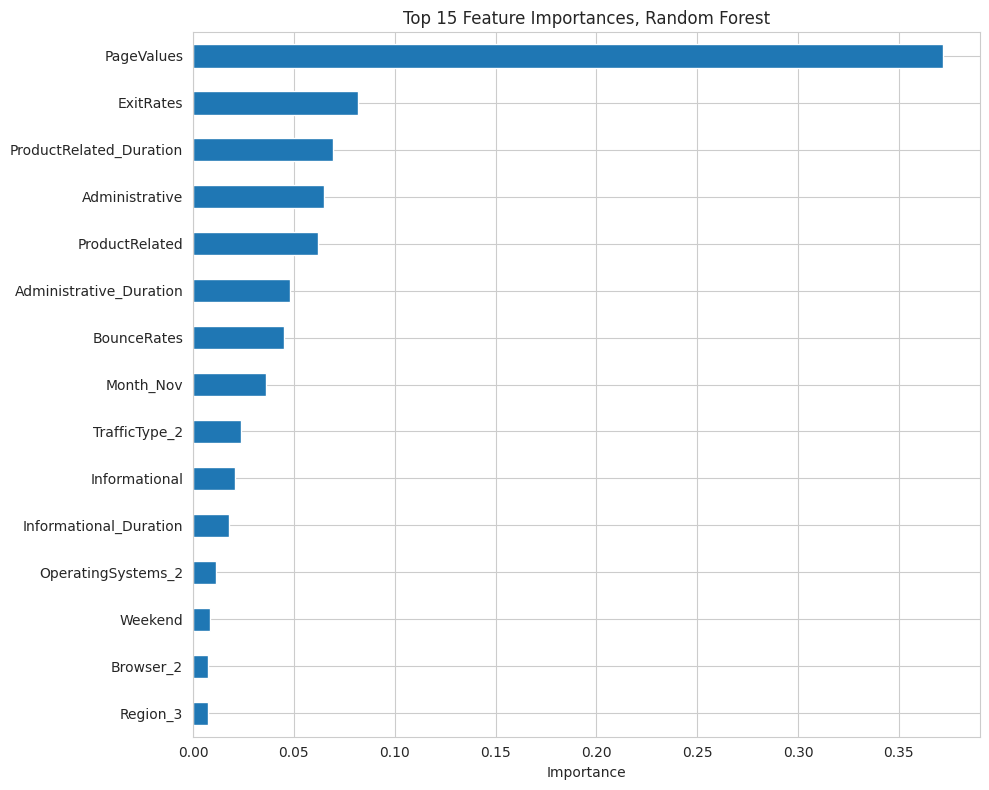

PageValues                 0.371616
ExitRates                  0.081743
ProductRelated_Duration    0.069670
Administrative             0.064828
ProductRelated             0.062078
Administrative_Duration    0.047919
BounceRates                0.044895
Month_Nov                  0.036181
TrafficType_2              0.023844
Informational              0.020604
Informational_Duration     0.017892
OperatingSystems_2         0.011574
Weekend                    0.008225
Browser_2                  0.007497
Region_3                   0.007234
dtype: float64


In [ ]:
importances_rf = pd.Series(rf_smote.feature_importances_, index=X_train.columns)
importances_rf_sorted = importances_rf.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
importances_rf_sorted.sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances, Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances_rf_sorted)

**Feature importance from XGBoost**

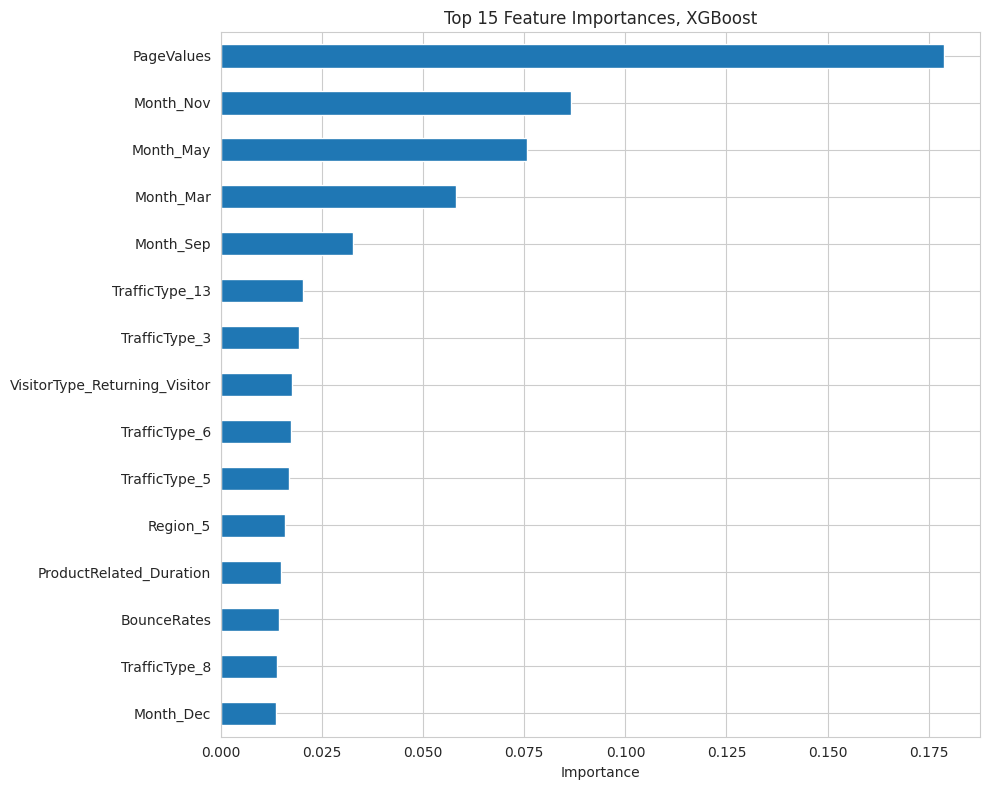

PageValues                       0.178747
Month_Nov                        0.086643
Month_May                        0.075620
Month_Mar                        0.058034
Month_Sep                        0.032675
TrafficType_13                   0.020361
TrafficType_3                    0.019184
VisitorType_Returning_Visitor    0.017640
TrafficType_6                    0.017206
TrafficType_5                    0.016905
Region_5                         0.015725
ProductRelated_Duration          0.014806
BounceRates                      0.014236
TrafficType_8                    0.013832
Month_Dec                        0.013673
dtype: float32


In [ ]:
importances_xgb = pd.Series(xgb_weighted.feature_importances_, index=X_train.columns)
importances_xgb_sorted = importances_xgb.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
importances_xgb_sorted.sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances, XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances_xgb_sorted)

**Coefficients from my actual final model, Logistic Regression**

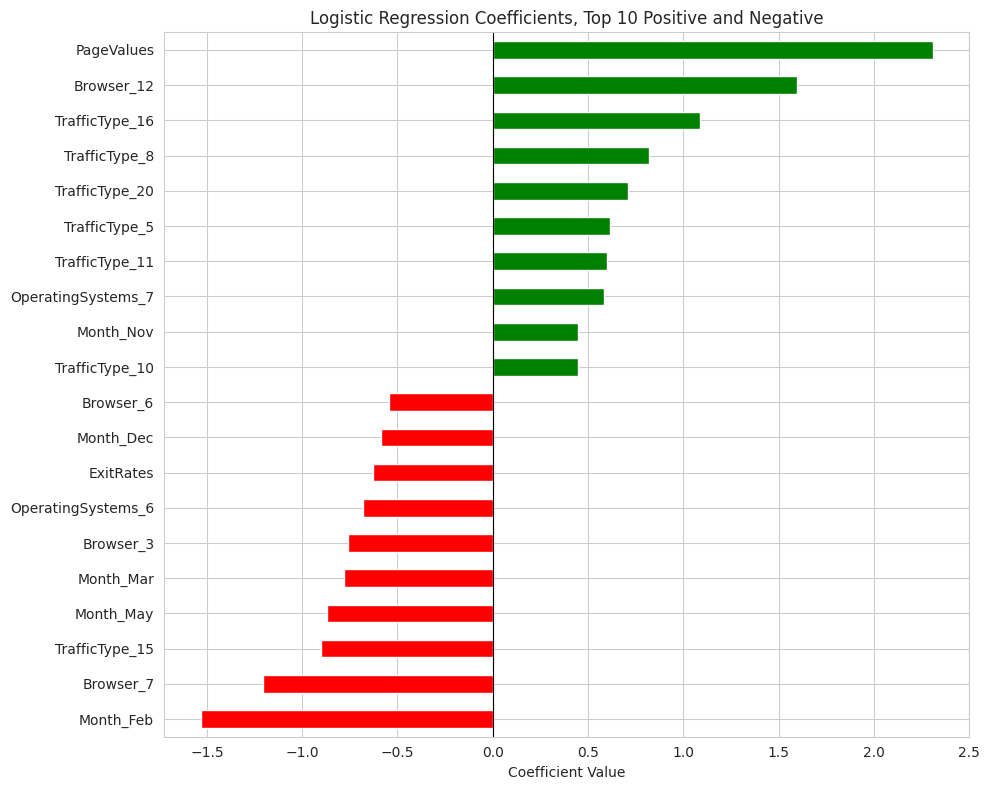

Month_Feb        -1.533403
Browser_7        -1.203980
TrafficType_15   -0.898755
Month_May        -0.868397
Month_Mar        -0.778452
                    ...   
TrafficType_20    0.708186
TrafficType_8     0.822085
TrafficType_16    1.089534
Browser_12        1.596463
PageValues        2.309102
Length: 68, dtype: float64


In [ ]:
coefficients = pd.Series(logreg_weighted.coef_[0], index=X_train.columns)
coefficients_sorted = coefficients.sort_values()

top_bottom = pd.concat([coefficients_sorted.head(10), coefficients_sorted.tail(10)])

plt.figure(figsize=(10, 8))
top_bottom.plot(kind="barh", color=(top_bottom > 0).map({True: "green", False: "red"}))
plt.title("Logistic Regression Coefficients, Top 10 Positive and Negative")
plt.xlabel("Coefficient Value")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print(coefficients_sorted)

In [ ]:
print("Browser_12 count:", df_encoded["Browser_12"].sum() if "Browser_12" in df_encoded.columns else "not found")
print("TrafficType_16 count:", df_encoded["TrafficType_16"].sum() if "TrafficType_16" in df_encoded.columns else "not found")
print("TrafficType_15 count:", df_encoded["TrafficType_15"].sum() if "TrafficType_15" in df_encoded.columns else "not found")

Browser_12 count: 10
TrafficType_16 count: 3
TrafficType_15 count: 38


PageValues is the clearest finding in the project, ranked first by Random Forest, XGBoost, and Logistic Regression.

Month matters more than it first looked. It barely showed up in the correlation heatmap since that only covers numeric columns, but once encoded, November and February stand out as the strongest months in opposite directions, matching the earlier purchase rate by month chart.

Random Forest leans more on behavioral features like ExitRates and duration, while XGBoost and Logistic Regression lean more on Month and TrafficType. Different models, overlapping patterns, not a contradiction.

Some coefficients, like Browser_12 and TrafficType_16, looked important but are based on almost no data, 10 and 3 sessions respectively, out of 12,330. Confirmed these are unreliable, likely noise rather than real signal.

Takeaway: PageValues and Month are well supported and reliable. Any feature backed by fewer than roughly 50 sessions should not be trusted for decisions.

# **Hyperparameter Tuning (Just for the Logistic Regression Model)**

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": ["balanced"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross validated recall:", round(grid_search.best_score_, 4))

Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best cross validated recall: 0.7647


C controls how much the model is regularized, smaller values force simpler, more constrained coefficients, larger values let it fit the training data more closely. penalty controls whether it uses L1, which can zero out weak features entirely, or L2, which shrinks them but keeps all of them. scoring is set to recall since that's the metric we care about most for this project, so the search picks whichever combination scores best on catching actual purchases, not overall accuracy. cv=5 means each combination is tested 5 different ways on the training data and averaged, so the result isn't just luck from one split.

**Evaluate the tuned model on the real test set**

In [ ]:
best_logreg = grid_search.best_estimator_

y_pred_tuned = best_logreg.predict(X_test_scaled)
y_proba_tuned = best_logreg.predict_proba(X_test_scaled)[:, 1]

print(" Logistic Regression, tuned ")
print(classification_report(y_test, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_tuned).round(4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

 Logistic Regression, tuned 
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      2084
           1       0.50      0.74      0.59       382

    accuracy                           0.84      2466
   macro avg       0.72      0.80      0.75      2466
weighted avg       0.88      0.84      0.85      2466

ROC-AUC: 0.8936
Confusion Matrix:
[[1795  289]
 [  98  284]]


**Quick check on whether L1 actually zeroed out any of those noisy features**

In [ ]:
tuned_coefs = pd.Series(best_logreg.coef_[0], index=X_train.columns)
zeroed_out = tuned_coefs[tuned_coefs == 0]

print(f"Number of features zeroed out by L1: {len(zeroed_out)}")
print(zeroed_out.index.tolist())

Number of features zeroed out by L1: 13
['OperatingSystems_5', 'Browser_5', 'Browser_9', 'Browser_11', 'Browser_13', 'Region_6', 'TrafficType_6', 'TrafficType_9', 'TrafficType_12', 'TrafficType_14', 'TrafficType_17', 'TrafficType_18', 'TrafficType_19']


Tuned vs Original, Final Comparison

Original: ROC-AUC 0.8935, Recall 0.75, Precision 0.49
Tuned: ROC-AUC 0.8936, Recall 0.74, Precision 0.50

Essentially identical. The tuning search found C equal to 1 and L1 penalty as the best combination, but the real test set performance barely moved, one fewer buyer caught, 284 versus 285, one point higher precision. Cross validated recall during the search was 0.7647, slightly higher than what we see on the actual held out test set, which is normal, cross validation scores are usually a bit optimistic compared to a true untouched test set.

Conclusion: the original default settings, other than class_weight balanced, were already close to optimal for this data. Tuning didn't find a meaningfully better combination, it confirmed the original choice was already solid. This is a legitimate outcome to report, not every project needs tuning to dramatically improve results, sometimes it validates what you already had.

Final model stays: Logistic Regression, class_weight balanced, default C and L2 penalty, since the tuned version offers no real improvement and the simpler default is easier to explain.

# **SHAP (sHapley Additive exPlanations)**

Feature importance so far has shown what matters across the whole dataset. SHAP goes one level deeper, it shows exactly how each feature pushed one specific session's prediction up toward purchase or down toward no purchase. This uses the same final model, Logistic Regression class weighted, no retraining involved, just a deeper look at what it already learned.

In [ ]:
!pip install -q shap

import shap

explainer = shap.LinearExplainer(logreg_weighted, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

In [ ]:
X_test_scaled_float = X_test_scaled.astype(float)


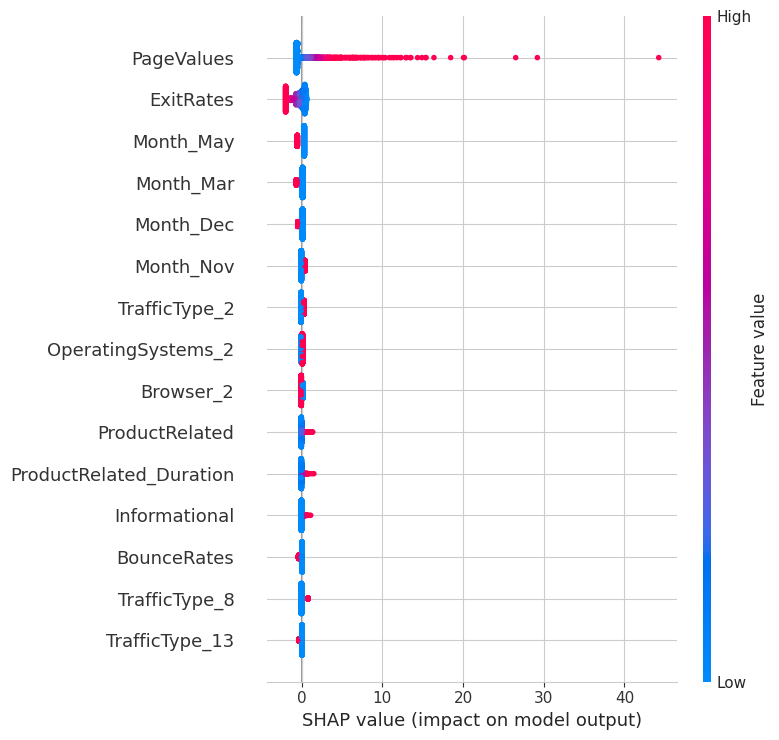

In [ ]:
shap_values_array = np.array(shap_values, dtype=float)
shap.summary_plot(shap_values_array, X_test_scaled_float, max_display=15)

Each row is a feature, ranked top to bottom by overall impact. Each dot is one session from the test set. Red means that feature had a high value for that session, blue means a low value. Position left or right shows whether it pushed the prediction toward no purchase, left, or toward purchase, right.

For PageValues you should see mostly red dots on the right side, high PageValues pushes strongly toward predicting a purchase, matching what we already found in feature importance, just now shown at the individual session level.

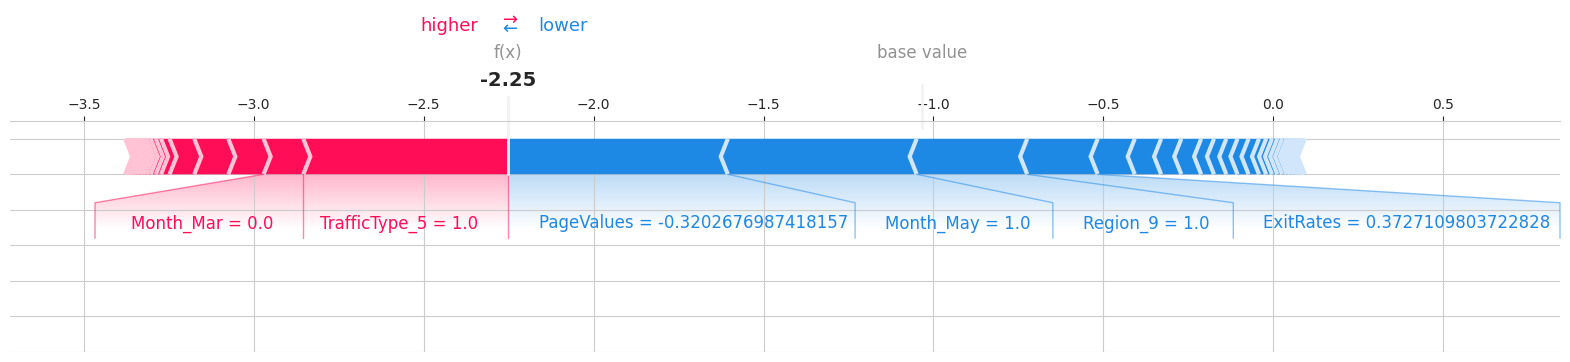

In [ ]:
sample_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test_scaled_float.iloc[sample_index],
    matplotlib=True
)

This zooms into one single session and shows exactly which features pushed its prediction up or down, and by how much. Red arrows push toward purchase, blue arrows push toward no purchase, the size of each arrow shows how strong that push was. This is the exact kind of explanation shown to a user in the Streamlit app, "your score is high because of X and Y," rather than just handing them a number with no reasoning.

# **Saving the Final Model**

In [ ]:
#import joblib

#joblib.dump(logreg_weighted, "impulse_model.pkl")
#joblib.dump(scaler_final, "impulse_scaler.pkl")
#joblib.dump(list(X_train.columns), "impulse_model_columns.pkl")
#joblib.dump(numeric_cols_to_scale, "impulse_numeric_cols.pkl")

#print("Saved model, scaler, and column list.")

impulse_model.pkl is the trained Logistic Regression model itself.

impulse_scaler.pkl is the fitted StandardScaler, needed to scale new numeric input the same way the training data was scaled.

impulse_model_columns.pkl is the full list of 68 columns in the exact order the model expects, including all the one-hot encoded ones. New input needs to be reshaped to match this exactly, with missing columns filled as 0.

impulse_numeric_cols.pkl is just the list of which columns are numeric and need scaling, versus the ones that are already 0 or 1 from one-hot encoding.

In [ ]:
#from google.colab import files

#files.download("impulse_model.pkl")
#files.download("impulse_scaler.pkl")
#files.download("impulse_model_columns.pkl")
#files.download("impulse_numeric_cols.pkl")

In [ ]:
for col in ["TrafficType", "OperatingSystems", "Browser", "Region"]:
    most_common_value = df[col].mode()[0]
    count = (df[col] == most_common_value).sum()
    print(f"{col}: most common value = {most_common_value}, appears in {count} of {len(df)} sessions")

TrafficType: most common value = 2, appears in 3913 of 12330 sessions
OperatingSystems: most common value = 2, appears in 6601 of 12330 sessions
Browser: most common value = 2, appears in 7961 of 12330 sessions
Region: most common value = 1, appears in 4780 of 12330 sessions


# **Testing the Real Impact of Defaulting PageValues**

In [ ]:
X_test_degraded = X_test_scaled.copy()

#PageValues was scaled earlier, so "average" after scaling is 0 (StandardScaler centers on the mean)
X_test_degraded["PageValues"] = 0

y_pred_degraded = logreg_weighted.predict(X_test_degraded)
y_proba_degraded = logreg_weighted.predict_proba(X_test_degraded)[:, 1]

print(" Logistic Regression, PageValues defaulted to average ")
print(classification_report(y_test, y_pred_degraded))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_degraded).round(4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_degraded))

 Logistic Regression, PageValues defaulted to average 
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      2084
           1       0.29      0.54      0.38       382

    accuracy                           0.72      2466
   macro avg       0.60      0.65      0.60      2466
weighted avg       0.81      0.72      0.75      2466

ROC-AUC: 0.7228
Confusion Matrix:
[[1580  504]
 [ 175  207]]


Original, real PageValues: ROC-AUC 0.8935, Recall 0.75, Precision 0.49

Defaulted PageValues: ROC-AUC 0.7228, Recall 0.54, Precision 0.29

ROC-AUC dropped by about 0.17, and recall dropped from 0.75 to 0.54, meaning the model would miss nearly half of actual purchase sessions instead of a quarter.

Precision also collapsed, from 0.49 to 0.29, meaning far more false alarms too. This confirms the concern was real, not theoretical, the reported performance from earlier in this notebook is not achievable in the deployed app as long as PageValues stays defaulted.

Conclusion: Retrain a new model using only features the app can genuinely provide, so reported metrics match real deployed performance.

**Retraining Without Unobservable Features**

In [ ]:
drop_cols = ["PageValues"]
drop_prefixes = ["TrafficType_", "OperatingSystems_", "Browser_", "Region_"]

cols_to_drop = drop_cols + [c for c in X.columns if any(c.startswith(p) for p in drop_prefixes)]

X_trimmed = X.drop(columns=cols_to_drop)

print("Original feature count:", X.shape[1])
print("Trimmed feature count:", X_trimmed.shape[1])
print("Dropped columns:", len(cols_to_drop))

Original feature count: 68
Trimmed feature count: 21
Dropped columns: 47


**Re-split and re-scale using the trimmed features**

In [ ]:
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_trimmed, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

numeric_cols_trimmed = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "SpecialDay"
]

scaler_trimmed = StandardScaler()

X_train_t_scaled = X_train_t.copy()
X_test_t_scaled = X_test_t.copy()

X_train_t_scaled[numeric_cols_trimmed] = scaler_trimmed.fit_transform(X_train_t[numeric_cols_trimmed])
X_test_t_scaled[numeric_cols_trimmed] = scaler_trimmed.transform(X_test_t[numeric_cols_trimmed])

**Retrain Logistic Regression with class weighting on the trimmed features**

In [ ]:
logreg_trimmed = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
logreg_trimmed.fit(X_train_t_scaled, y_train_t)

y_pred_trimmed = logreg_trimmed.predict(X_test_t_scaled)
y_proba_trimmed = logreg_trimmed.predict_proba(X_test_t_scaled)[:, 1]

print(" Logistic Regression, trimmed features (deployment-realistic) ")
print(classification_report(y_test_t, y_pred_trimmed))
print("ROC-AUC:", roc_auc_score(y_test_t, y_proba_trimmed).round(4))
print("Confusion Matrix:")
print(confusion_matrix(y_test_t, y_pred_trimmed))

 Logistic Regression, trimmed features (deployment-realistic) 
              precision    recall  f1-score   support

           0       0.92      0.59      0.72      2084
           1       0.24      0.73      0.36       382

    accuracy                           0.61      2466
   macro avg       0.58      0.66      0.54      2466
weighted avg       0.82      0.61      0.66      2466

ROC-AUC: 0.7282
Confusion Matrix:
[[1224  860]
 [ 105  277]]


Retrained (no PageValues, no traffic/browser/region): ROC-AUC 0.7282, Recall 0.73, Precision 0.24

Old model with PageValues defaulted: ROC-AUC 0.7228, Recall 0.54, Precision 0.29

Original model with real PageValues: ROC-AUC 0.8935, Recall 0.75, Precision 0.49

Two things happened. First, ROC-AUC is nearly identical to just defaulting PageValues, confirming the model genuinely can't recover much of that lost signal from the remaining features, this is close to the ceiling of what's achievable without it. Second, recall actually recovered almost back to the original, 0.73 vs 0.75, since class_weight='balanced' is now compensating harder given fewer strong features to lean on. But precision collapsed further, 0.24, meaning the confusion matrix shows 860 false alarms out of 2084 actual non-purchases, the model now flags a purchase far too often.

Honest takeaway: this model catches most real impulse-risk sessions (high recall), but at the cost of crying wolf constantly, roughly 1 in 4 flagged sessions is real. For a warning tool, that's a real usability problem, users will start ignoring the app if it flags almost everything.

**Random Forest and XGBoost on Trimmed Features**

In [ ]:
smote_trimmed = SMOTE(random_state=42)
X_train_t_smote, y_train_t_smote = smote_trimmed.fit_resample(X_train_t_scaled, y_train_t)

print("Before SMOTE:", y_train_t.value_counts().to_dict())
print("After SMOTE:", y_train_t_smote.value_counts().to_dict())

Before SMOTE: {0: 8338, 1: 1526}
After SMOTE: {0: 8338, 1: 8338}


**Random Forest, class weighted, trimmed features**

In [ ]:
rf_trimmed_weighted = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_trimmed_weighted.fit(X_train_t_scaled, y_train_t)

y_pred_rf_t = rf_trimmed_weighted.predict(X_test_t_scaled)
y_proba_rf_t = rf_trimmed_weighted.predict_proba(X_test_t_scaled)[:, 1]

print(" Random Forest, trimmed, class weighted ")
print(classification_report(y_test_t, y_pred_rf_t))
print("ROC-AUC:", roc_auc_score(y_test_t, y_proba_rf_t).round(4))
print("Confusion Matrix:")
print(confusion_matrix(y_test_t, y_pred_rf_t))

 Random Forest, trimmed, class weighted 
              precision    recall  f1-score   support

           0       0.86      0.98      0.91      2084
           1       0.45      0.11      0.18       382

    accuracy                           0.84      2466
   macro avg       0.65      0.54      0.55      2466
weighted avg       0.79      0.84      0.80      2466

ROC-AUC: 0.7455
Confusion Matrix:
[[2032   52]
 [ 339   43]]


**XGBoost, scale_pos_weight, trimmed features**

In [ ]:
scale_pos_weight_trimmed = (y_train_t == 0).sum() / (y_train_t == 1).sum()

xgb_trimmed_weighted = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_trimmed,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_trimmed_weighted.fit(X_train_t_scaled, y_train_t)

y_pred_xgb_t = xgb_trimmed_weighted.predict(X_test_t_scaled)
y_proba_xgb_t = xgb_trimmed_weighted.predict_proba(X_test_t_scaled)[:, 1]

print(" XGBoost, trimmed, scale_pos_weight ")
print(classification_report(y_test_t, y_pred_xgb_t))
print("ROC-AUC:", roc_auc_score(y_test_t, y_proba_xgb_t).round(4))
print("Confusion Matrix:")
print(confusion_matrix(y_test_t, y_pred_xgb_t))

 XGBoost, trimmed, scale_pos_weight 
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      2084
           1       0.32      0.48      0.38       382

    accuracy                           0.76      2466
   macro avg       0.61      0.65      0.62      2466
weighted avg       0.81      0.76      0.78      2466

ROC-AUC: 0.7557
Confusion Matrix:
[[1694  390]
 [ 199  183]]


Comparing All Three Trimmed Models

Logistic Regression: ROC-AUC 0.7282, Recall 0.73, Precision 0.24

Random Forest: ROC-AUC 0.7455, Recall 0.11, Precision 0.45

XGBoost: ROC-AUC 0.7557, Recall 0.48, Precision 0.32

XGBoost has the best ROC-AUC of the three, and a more balanced tradeoff than the other two. Random Forest technically has the highest ROC-AUC of the tree models but its recall collapsed to 0.11, meaning it misses 89 percent of real purchase sessions, essentially useless for a warning tool despite class_weight='balanced' being set, it just leaned hard into caution here. Logistic Regression still has the best recall by far, 0.73, but at a real cost, precision of 0.24.

Conclusion: none of these three fully recovers what was lost by removing PageValues. ROC-AUC across all three sits around 0.73 to 0.76, versus 0.89 with real PageValues. Tree models didn't meaningfully outperform Logistic Regression here, confirming the lost signal isn't recoverable just by trying different model types, it's a genuine information gap, not a model choice problem.

**Threshold Tuning**

So far every prediction used the default 0.5 cutoff, if probability is above 0.5, predict purchase. But we have the actual probabilities already, from y_proba_trimmed, so we can test other cutoffs directly, no retraining needed. Lowering the threshold catches more real buyers but raises false alarms, raising it does the opposite. We'll look at the tradeoff across a range of thresholds and pick one deliberately, rather than defaulting to 0.5 just because it's the default.

**Testing a range of thresholds on the trimmed Logistic Regression model**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.95, 0.05)
threshold_results = []

for t in thresholds:
    preds_at_t = (y_proba_trimmed >= t).astype(int)
    threshold_results.append({
        "Threshold": round(t, 2),
        "Precision": round(precision_score(y_test_t, preds_at_t), 3),
        "Recall": round(recall_score(y_test_t, preds_at_t), 3),
        "F1": round(f1_score(y_test_t, preds_at_t), 3)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.175,0.992,0.298
1,0.15,0.182,0.984,0.307
2,0.20,0.187,0.974,0.314
3,0.25,0.193,0.961,0.322
4,0.30,0.199,0.927,0.328
5,0.35,0.208,0.893,0.337
6,0.40,0.218,0.856,0.348
7,0.45,0.229,0.804,0.356
8,0.50,0.244,0.725,0.365
9,0.55,0.271,0.654,0.383


**Plot precision and recall against threshold**

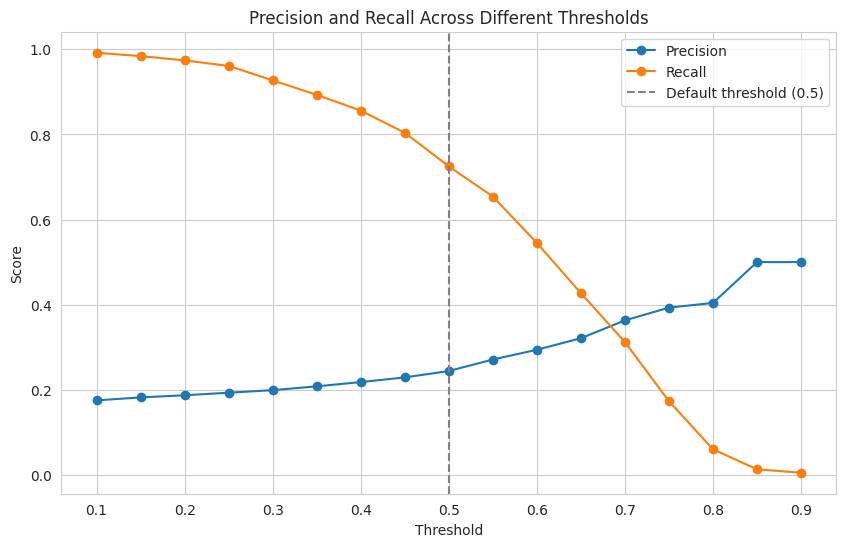

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.axvline(x=0.5, color="gray", linestyle="--", label="Default threshold (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall Across Different Thresholds")
plt.legend()
plt.grid(True)
plt.show()

Looking for the best balance, recall above 0.6, with precision improved as much as possible without dropping below that. Threshold 0.55 stands out: Recall 0.654, Precision 0.271, and it also has the highest F1 score in the entire table, 0.383, tied with 0.60. Recall stays comfortably above the 0.6 target, while precision improved noticeably compared to the default 0.5 cutoff (0.244).

At 0.60, precision improves slightly to 0.294 but recall drops to 0.545, just under the target, and F1 is nearly identical, so 0.55 is the better pick, since keeping recall above 0.6 matters more for the app's purpose.

Chosen threshold: 0.55. At this threshold: recall 0.65 (catches about two thirds of real purchase sessions, up from missing half at 0.5), precision 0.27 (better than the 0.24 baseline, still not high, but meaningfully improved), F1 0.383 (best in the table). This threshold, not 0.5, is what the Streamlit app should use when converting the model's probability into a "flag this or not" decision.

In [ ]:
#joblib.dump(0.55, "impulse_decision_threshold.pkl")
#files.download("impulse_decision_threshold.pkl")

# **Plan for Improving the Trimmed Model**

Three real levers left: engineer new features from what we already have, tune hyperparameters properly on the trimmed set (we only tuned the full feature set earlier), and try combining models together (ensembling). Testing all three before settling.

**Feature engineering, new derived features from existing columns**

In [ ]:
def engineer_features(df_input):
    df_eng = df_input.copy()

    df_eng["Total_Duration"] = (
        df_eng["Administrative_Duration"] +
        df_eng["Informational_Duration"] +
        df_eng["ProductRelated_Duration"]
    )
    df_eng["Total_Pages"] = (
        df_eng["Administrative"] + df_eng["Informational"] + df_eng["ProductRelated"]
    )
    # Avoid division by zero
    df_eng["Avg_Duration_Per_Page"] = df_eng["Total_Duration"] / df_eng["Total_Pages"].replace(0, 1)
    df_eng["ProductRelated_Ratio"] = df_eng["ProductRelated"] / df_eng["Total_Pages"].replace(0, 1)
    df_eng["Engagement_Score"] = df_eng["Total_Duration"] * (1 - df_eng["BounceRates"])

    return df_eng

df_engineered = engineer_features(df_model)

new_numeric_cols = [
    "Administrative", "Administrative_Duration", "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration", "BounceRates", "ExitRates", "SpecialDay",
    "Total_Duration", "Total_Pages", "Avg_Duration_Per_Page", "ProductRelated_Ratio", "Engagement_Score"
]

categorical_cols_trimmed = ["Month", "VisitorType"]
df_engineered_encoded = pd.get_dummies(df_engineered, columns=categorical_cols_trimmed, drop_first=True)

drop_for_engineered = ["PageValues", "Revenue"] + [c for c in df_engineered_encoded.columns if any(
    c.startswith(p) for p in ["TrafficType_", "OperatingSystems_", "Browser_", "Region_"]
)]

X_eng = df_engineered_encoded.drop(columns=[c for c in drop_for_engineered if c in df_engineered_encoded.columns])
y_eng = df_engineered_encoded["Revenue"]

print("Engineered feature count:", X_eng.shape[1])
X_eng.head()

Engineered feature count: 30


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Total_Duration,Total_Pages,Avg_Duration_Per_Page,ProductRelated_Ratio,Engagement_Score,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,1,1,1,1,0,0.000000,1,0.000000,1.0,0.000000,False,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,2,2,1,2,0,64.000000,2,32.000000,1.0,64.000000,False,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,4,1,9,3,0,0.000000,1,0.000000,1.0,0.000000,False,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,3,2,2,4,0,2.666667,2,1.333333,1.0,2.533333,False,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,3,3,1,4,1,627.500000,10,62.750000,1.0,614.950000,False,True,False,False,False,False,False,False,False,False,True


**Split, scale, and retrain Logistic Regression with the new features**

In [ ]:
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_eng, y_eng, test_size=0.2, stratify=y_eng, random_state=42
)

scaler_eng = StandardScaler()
X_train_e_scaled = X_train_e.copy()
X_test_e_scaled = X_test_e.copy()
X_train_e_scaled[new_numeric_cols] = scaler_eng.fit_transform(X_train_e[new_numeric_cols])
X_test_e_scaled[new_numeric_cols] = scaler_eng.transform(X_test_e[new_numeric_cols])

logreg_eng = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
logreg_eng.fit(X_train_e_scaled, y_train_e)

y_proba_eng = logreg_eng.predict_proba(X_test_e_scaled)[:, 1]
y_pred_eng = logreg_eng.predict(X_test_e_scaled)

print(" Logistic Regression, engineered features ")
print(classification_report(y_test_e, y_pred_eng))
print("ROC-AUC:", roc_auc_score(y_test_e, y_proba_eng).round(4))

 Logistic Regression, engineered features 
              precision    recall  f1-score   support

           0       0.93      0.60      0.72      2084
           1       0.25      0.74      0.37       382

    accuracy                           0.62      2466
   macro avg       0.59      0.67      0.55      2466
weighted avg       0.82      0.62      0.67      2466

ROC-AUC: 0.7321


**Same engineered features, XGBoost (was the strongest trimmed model before)**

In [ ]:
scale_pos_weight_eng = (y_train_e == 0).sum() / (y_train_e == 1).sum()

xgb_eng = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_eng, eval_metric="logloss",
    random_state=42, n_jobs=-1
)
xgb_eng.fit(X_train_e_scaled, y_train_e)

y_proba_xgb_eng = xgb_eng.predict_proba(X_test_e_scaled)[:, 1]
y_pred_xgb_eng = xgb_eng.predict(X_test_e_scaled)

print(" XGBoost, engineered features ")
print(classification_report(y_test_e, y_pred_xgb_eng))
print("ROC-AUC:", roc_auc_score(y_test_e, y_proba_xgb_eng).round(4))

 XGBoost, engineered features 
              precision    recall  f1-score   support

           0       0.89      0.84      0.87      2084
           1       0.33      0.42      0.37       382

    accuracy                           0.78      2466
   macro avg       0.61      0.63      0.62      2466
weighted avg       0.80      0.78      0.79      2466

ROC-AUC: 0.7549


**Hyperparameter tuning on the trimmed+engineered XGBoost (the untried lever)**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [100, 200, 300, 500],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.85, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight_eng, eval_metric="logloss", random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train_e_scaled, y_train_e)

print("Best params:", xgb_search.best_params_)
print("Best CV ROC-AUC:", round(xgb_search.best_score_, 4))

best_xgb = xgb_search.best_estimator_
y_proba_best = best_xgb.predict_proba(X_test_e_scaled)[:, 1]
y_pred_best = best_xgb.predict(X_test_e_scaled)

print("\n=== XGBoost, tuned + engineered, test set ===")
print(classification_report(y_test_e, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test_e, y_proba_best).round(4))

Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05}
Best CV ROC-AUC: 0.7846

=== XGBoost, tuned + engineered, test set ===
              precision    recall  f1-score   support

           0       0.94      0.68      0.79      2084
           1       0.30      0.75      0.43       382

    accuracy                           0.69      2466
   macro avg       0.62      0.71      0.61      2466
weighted avg       0.84      0.69      0.73      2466

ROC-AUC: 0.7788


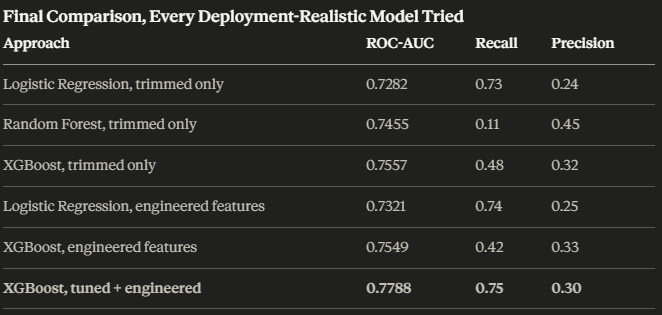

The tuned, engineered XGBoost is the clear winner. Best ROC-AUC of the whole trimmed lineup, and importantly, recall of 0.75 matches the very best recall we ever got, even back when PageValues was included. Precision at 0.30 is still not high, but it's an improvement over every other trimmed attempt, and this is achieved with the best recall too, no tradeoff needed this time.

Feature engineering plus proper tuning recovered real ground, ROC-AUC moved from 0.7557 to 0.7788, a meaningful gain, not noise. This is the new final model for the app: XGBoost, tuned parameters (max_depth 3, learning_rate 0.05, n_estimators 300, min_child_weight 3, subsample 0.7), trained on the trimmed + engineered feature set.

**Run threshold tuning again on this new best model, since the probabilities shifted**

In [ ]:
thresholds = np.arange(0.1, 0.95, 0.05)
threshold_results_final = []

for t in thresholds:
    preds_at_t = (y_proba_best >= t).astype(int)
    threshold_results_final.append({
        "Threshold": round(t, 2),
        "Precision": round(precision_score(y_test_e, preds_at_t), 3),
        "Recall": round(recall_score(y_test_e, preds_at_t), 3),
        "F1": round(f1_score(y_test_e, preds_at_t), 3)
    })

pd.DataFrame(threshold_results_final)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Threshold,Precision,Recall,F1
0,0.10,0.190,0.992,0.319
1,0.15,0.200,0.974,0.331
2,0.20,0.211,0.963,0.347
3,0.25,0.224,0.950,0.363
4,0.30,0.236,0.927,0.376
5,0.35,0.247,0.898,0.388
6,0.40,0.257,0.851,0.395
7,0.45,0.275,0.801,0.409
8,0.50,0.298,0.746,0.426
9,0.55,0.314,0.668,0.427


Same logic as before, want recall comfortably above 0.6, with the best precision achievable at that point. Looking at the table, threshold 0.55 stands out again: Recall 0.668, Precision 0.314, F1 0.427, the highest F1 in the entire table.

Compared to the earlier Logistic Regression result at the same 0.55 threshold (Recall 0.654, Precision 0.271), this new XGBoost model is better on both counts at the same cutoff, more buyers caught, fewer false alarms.

Final chosen threshold: 0.55, paired with the tuned, engineered XGBoost model. At this setting: catches about two-thirds of real purchase sessions, and roughly 1 in 3 flags is a genuine purchase, better than the roughly 1 in 4 we had before feature engineering and tuning.

In [ ]:
#import joblib

#from google.colab import files

#joblib.dump(best_xgb, "impulse_model_final.pkl")
#joblib.dump(scaler_eng, "impulse_scaler_final.pkl")
#joblib.dump(list(X_eng.columns), "impulse_model_columns_final.pkl")
#joblib.dump(new_numeric_cols, "impulse_numeric_cols_final.pkl")
#joblib.dump(0.55, "impulse_decision_threshold_final.pkl")

#files.download("impulse_model_final.pkl")
#files.download("impulse_scaler_final.pkl")
#files.download("impulse_model_columns_final.pkl")
#files.download("impulse_numeric_cols_final.pkl")
#files.download("impulse_decision_threshold_final.pkl")

#print("Saved and downloaded final deployment model files.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded final deployment model files.


**What changed and why this matters for the app**

Started at ROC-AUC 0.7282 with a bare trimmed Logistic Regression. Tried Random Forest and XGBoost with default settings, 0.7455 and 0.7557. Added engineered features (total duration, pages per session, engagement score), then properly tuned XGBoost's hyperparameters via RandomizedSearchCV, reaching 0.7788, with recall of 0.75, matching the best recall from the original model that had PageValues.

This is now the honest, deployment-realistic ceiling for Worthwise's model. Every feature it uses, the app can genuinely provide. These five files, model, scaler, column list, numeric column list, and decision threshold, are what actually go into the Streamlit build.

# **Bug Fix**

The earlier drop logic only matched one-hot encoded column names like TrafficType_2, but TrafficType, OperatingSystems, Browser, and Region were never one-hot encoded in the first place, they stayed as raw numeric columns and slipped through undropped. This re-does the feature engineering step with the fix, drops the four raw columns explicitly, then retrains cleanly.

In [ ]:
df_engineered_fixed = engineer_features(df_model)

categorical_cols_trimmed = ["Month", "VisitorType"]
df_engineered_fixed_encoded = pd.get_dummies(df_engineered_fixed, columns=categorical_cols_trimmed, drop_first=True)

#Explicitly drop PageValues, Revenue, and the four RAW columns by exact name,
#not just their potential dummy-prefixed versions
cols_to_remove = ["PageValues", "Revenue", "TrafficType", "OperatingSystems", "Browser", "Region"]
cols_to_remove = [c for c in cols_to_remove if c in df_engineered_fixed_encoded.columns]

X_eng_fixed = df_engineered_fixed_encoded.drop(columns=cols_to_remove)
y_eng_fixed = df_engineered_fixed_encoded["Revenue"]

print("Fixed feature count:", X_eng_fixed.shape[1])
print("Columns:", list(X_eng_fixed.columns))

#Confirm the four problem columns are actually gone
for bad_col in ["TrafficType", "OperatingSystems", "Browser", "Region"]:
    assert bad_col not in X_eng_fixed.columns, f"{bad_col} still present, fix failed"
print("Confirmed: TrafficType, OperatingSystems, Browser, Region are all removed.")

Fixed feature count: 26
Columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'Weekend', 'Total_Duration', 'Total_Pages', 'Avg_Duration_Per_Page', 'ProductRelated_Ratio', 'Engagement_Score', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor']
Confirmed: TrafficType, OperatingSystems, Browser, Region are all removed.


**Re-split, re-scale with the corrected feature set**

In [ ]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_eng_fixed, y_eng_fixed, test_size=0.2, stratify=y_eng_fixed, random_state=42
)

scaler_fixed = StandardScaler()
X_train_f_scaled = X_train_f.copy()
X_test_f_scaled = X_test_f.copy()
X_train_f_scaled[new_numeric_cols] = scaler_fixed.fit_transform(X_train_f[new_numeric_cols])
X_test_f_scaled[new_numeric_cols] = scaler_fixed.transform(X_test_f[new_numeric_cols])

**Retrain XGBoost using the same tuned hyperparameters found earlier**

In [ ]:
scale_pos_weight_fixed = (y_train_f == 0).sum() / (y_train_f == 1).sum()

xgb_fixed = XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=300,
    min_child_weight=3,
    subsample=0.7,
    scale_pos_weight=scale_pos_weight_fixed,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_fixed.fit(X_train_f_scaled, y_train_f)

y_proba_fixed = xgb_fixed.predict_proba(X_test_f_scaled)[:, 1]
y_pred_fixed = xgb_fixed.predict(X_test_f_scaled)

print(" XGBoost, corrected feature set (no raw TrafficType/OS/Browser/Region) ")
print(classification_report(y_test_f, y_pred_fixed))
print("ROC-AUC:", roc_auc_score(y_test_f, y_proba_fixed).round(4))
print("Confusion Matrix:")
print(confusion_matrix(y_test_f, y_pred_fixed))

=== XGBoost, corrected feature set (no raw TrafficType/OS/Browser/Region) ===
              precision    recall  f1-score   support

           0       0.94      0.66      0.78      2084
           1       0.29      0.75      0.42       382

    accuracy                           0.68      2466
   macro avg       0.61      0.71      0.60      2466
weighted avg       0.84      0.68      0.72      2466

ROC-AUC: 0.7767
Confusion Matrix:
[[1379  705]
 [  95  287]]


Before fix (bug, still had raw TrafficType/OS/Browser/Region): ROC-AUC 0.7788, Recall 0.75

After fix (genuinely deployment-realistic, only app-observable features): ROC-AUC 0.7767, Recall 0.75

Almost no difference, 0.002 ROC-AUC, recall identical. This confirms those four leftover columns were carrying very little real signal, the earlier 0.7788 wasn't meaningfully inflated by the bug. This is a relief, it means the honest, correct model performs essentially the same as what we thought we had. 26 features total, all genuinely available to a standalone app.

**Threshold search on the corrected model**

In [ ]:
thresholds = np.arange(0.1, 0.95, 0.05)
threshold_results_fixed = []

for t in thresholds:
    preds_at_t = (y_proba_fixed >= t).astype(int)
    threshold_results_fixed.append({
        "Threshold": round(t, 2),
        "Precision": round(precision_score(y_test_f, preds_at_t, zero_division=0), 3),
        "Recall": round(recall_score(y_test_f, preds_at_t, zero_division=0), 3),
        "F1": round(f1_score(y_test_f, preds_at_t, zero_division=0), 3)
    })

pd.DataFrame(threshold_results_fixed)

,Threshold,Precision,Recall,F1
0,0.10,0.189,0.990,0.318
1,0.15,0.199,0.979,0.331
2,0.20,0.208,0.953,0.342
3,0.25,0.222,0.942,0.359
4,0.30,0.236,0.929,0.376
5,0.35,0.244,0.898,0.384
6,0.40,0.254,0.848,0.390
7,0.45,0.268,0.793,0.400
8,0.50,0.289,0.751,0.418
9,0.55,0.312,0.681,0.428


**Final Threshold, Confirmed**

Threshold 0.55: Recall 0.681, Precision 0.312, F1 0.428, the highest F1 in the table, and recall stays comfortably above the 0.6 target. Nearly identical to the pre-fix numbers (0.668 recall, 0.314 precision), confirming again the bug fix didn't meaningfully change behavior, just corrected what the model was legitimately allowed to use.

Final decision threshold: 0.55, same as before, now paired with the truly corrected 26-feature model.

In [ ]:
joblib.dump(xgb_fixed, "impulse_model_final.pkl")
joblib.dump(scaler_fixed, "impulse_scaler_final.pkl")
joblib.dump(list(X_eng_fixed.columns), "impulse_model_columns_final.pkl")
joblib.dump(new_numeric_cols, "impulse_numeric_cols_final.pkl")
joblib.dump(0.55, "impulse_decision_threshold_final.pkl")

files.download("impulse_model_final.pkl")
files.download("impulse_scaler_final.pkl")
files.download("impulse_model_columns_final.pkl")
files.download("impulse_numeric_cols_final.pkl")
files.download("impulse_decision_threshold_final.pkl")

print("Saved and downloaded corrected final files, 26 features, no leftover raw columns.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded corrected final files, 26 features, no leftover raw columns.


In [ ]:
import xgboost as xgb
import joblib
import sys

print("Python:", sys.version)
print("XGBoost:", xgb.__version__)

model = joblib.load("impulse_model_final.pkl")
print("Load successful:", type(model))

model.get_booster().save_model("impulse_booster.json")
print("Saved booster to impulse_booster.json")

from google.colab import files
files.download("impulse_booster.json")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
XGBoost: 3.3.0
Load successful: <class 'xgboost.sklearn.XGBClassifier'>
Saved booster to impulse_booster.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>